In [10]:
from tdc.single_pred import Tox
from rdkit import Chem, RDLogger
from rdkit.Chem import Lipinski, Descriptors, Crippen,rdMolDescriptors, GraphDescriptors, QED
from rdkit.Chem import Fragments, AllChem
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)

RDLogger.DisableLog('rdApp.*')

from copy import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Optional GPU acceleration (RAPIDS)
GPU_AVAILABLE = False
GPU_BACKEND = 'CPU (scikit-learn)'
cp = None
cuLinearRegression = None
try:
    import cupy as cp
    from cuml.linear_model import LinearRegression as cuLinearRegression
    GPU_AVAILABLE = True
    GPU_BACKEND = 'GPU (RAPIDS cuML)'
except Exception:
    pass

# Local utilities
import sys
sys.path.insert(0, '.')

random_state = 0

In [11]:
df = pd.read_csv('../data/processed/train.csv')
print(f'Compute backend: {GPU_BACKEND}')
if not GPU_AVAILABLE:
    print('GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.')

Compute backend: CPU (scikit-learn)
GPU non rilevata o librerie RAPIDS mancanti. Uso CPU.


## Exploratory Data Analysis (EDA)

In [4]:
# Basic dataset info
print(f"Dataset Shape: {df.shape}")
print(f"\nMissing Values: {df.isnull().sum().sum()} total")
print("\nTarget Column (LD50) Stats:")
print(df['Y'].describe())

Dataset Shape: (5170, 1817)

Missing Values: 0 total

Target Column (LD50) Stats:
count    5170.000000
mean        2.537543
std         0.959473
min        -0.343000
25%         1.854000
50%         2.366000
75%         3.023000
max        10.207000
Name: Y, dtype: float64


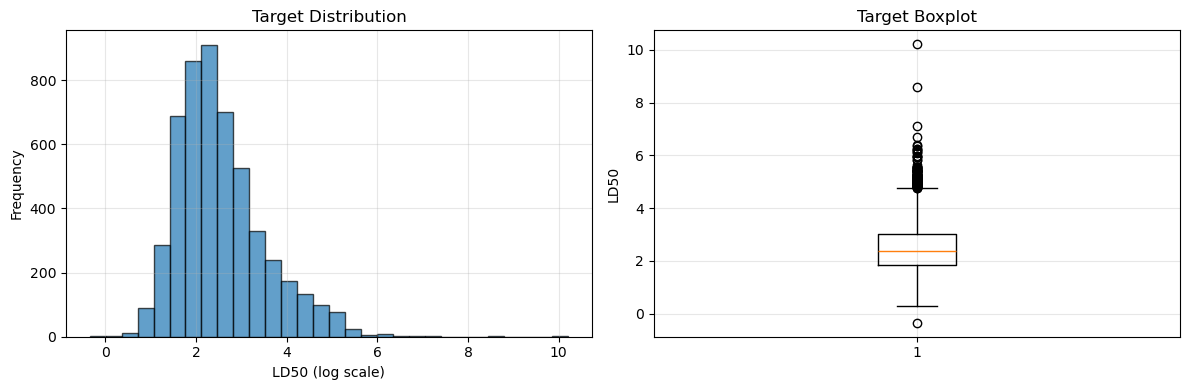

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Y'], bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('LD50 (log scale)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution')
axes[0].grid(alpha=0.3)

axes[1].boxplot(df['Y'], vert=True)
axes[1].set_ylabel('LD50')
axes[1].set_title('Target Boxplot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Top 15 features by |Spearman correlation|:
                     corr           pval  abs_corr
mordred_MIC1     0.455740  1.313947e-263  0.455740
mordred_MIC2     0.444235  5.021438e-249  0.444235
mordred_ATS0m    0.435950  7.204524e-239  0.435950
mordred_ATS0Z    0.435435  3.023507e-238  0.435435
mordred_ATS2m    0.433083  2.029215e-235  0.433083
mordred_ATS1m    0.430216  5.298093e-232  0.430216
mordred_MIC3     0.427887  2.986553e-229  0.427887
mordred_MIC4     0.422806  2.529877e-223  0.422806
mordred_ATS2Z    0.421187  1.864749e-221  0.421187
mordred_MIC5     0.420811  5.032848e-221  0.420811
mordred_MID_h    0.418281  3.946855e-218  0.418281
mordred_SM1_Dzm  0.418027  7.678753e-218  0.418027
mordred_SM1_DzZ  0.416954  1.271705e-216  0.416954
mordred_ATS1Z    0.415492  5.719633e-215  0.415492
mordred_ATS3m    0.409754  1.473798e-208  0.409754


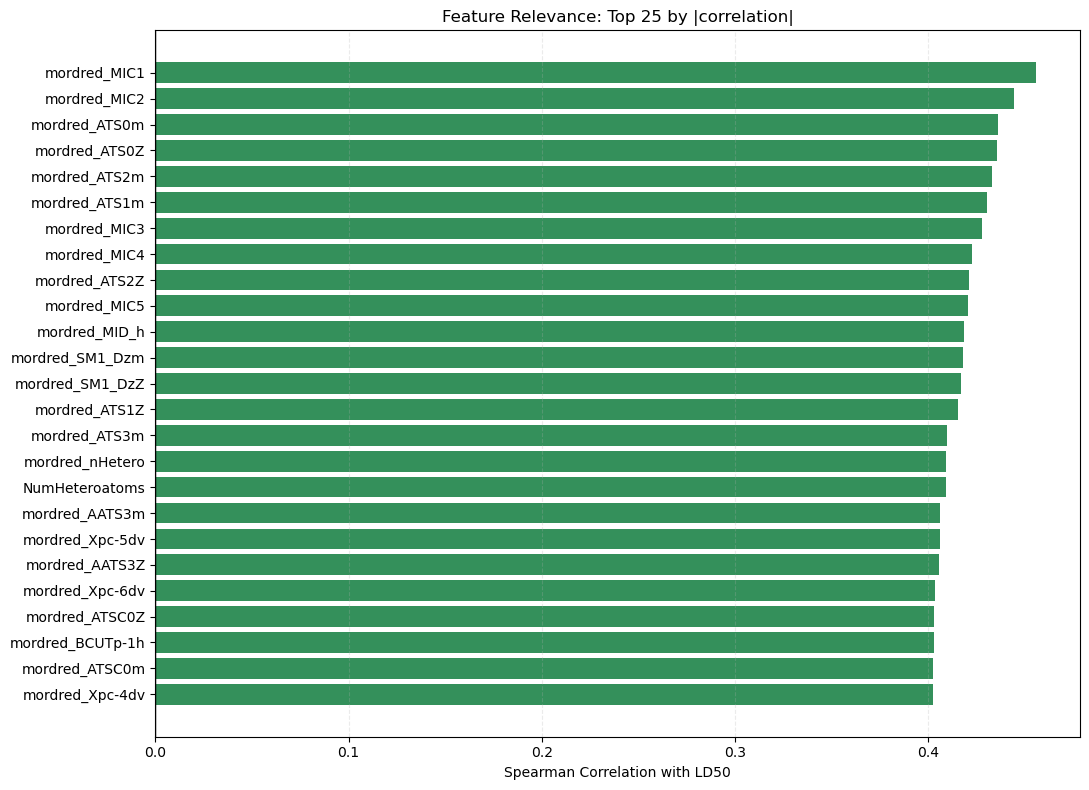

In [12]:
# Feature relevance: Spearman correlations with target
descriptor_cols = df.select_dtypes(include=[np.number]).columns.difference(['Y'])
correlations = {}

for col in descriptor_cols:
    valid_mask = (df[col].notna()) & (df['Y'].notna())
    if valid_mask.sum() > 0:
        corr, pval = spearmanr(df[col][valid_mask], df['Y'][valid_mask])
        correlations[col] = {'corr': corr, 'pval': pval, 'abs_corr': abs(corr)}

corr_df = pd.DataFrame(correlations).T.sort_values('abs_corr', ascending=False)
corr_df_clean = corr_df.dropna(subset=['corr']).copy()

print('Top 15 features by |Spearman correlation|:')
print(corr_df_clean.head(15)[['corr', 'pval', 'abs_corr']])

# Visualization (readable: only top features by absolute correlation)
top_k_plot = 25
plot_df = corr_df_clean.head(top_k_plot).sort_values('corr')
colors = ['#c0392b' if x < 0 else '#1e8449' for x in plot_df['corr']]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_df.index, plot_df['corr'], color=colors, alpha=0.9)
ax.set_xlabel('Spearman Correlation with LD50')
ax.set_title(f'Feature Relevance: Top {top_k_plot} by |correlation|')
ax.axvline(0, color='black', linewidth=1)
ax.grid(alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

Correlation backend: CPU (pandas)


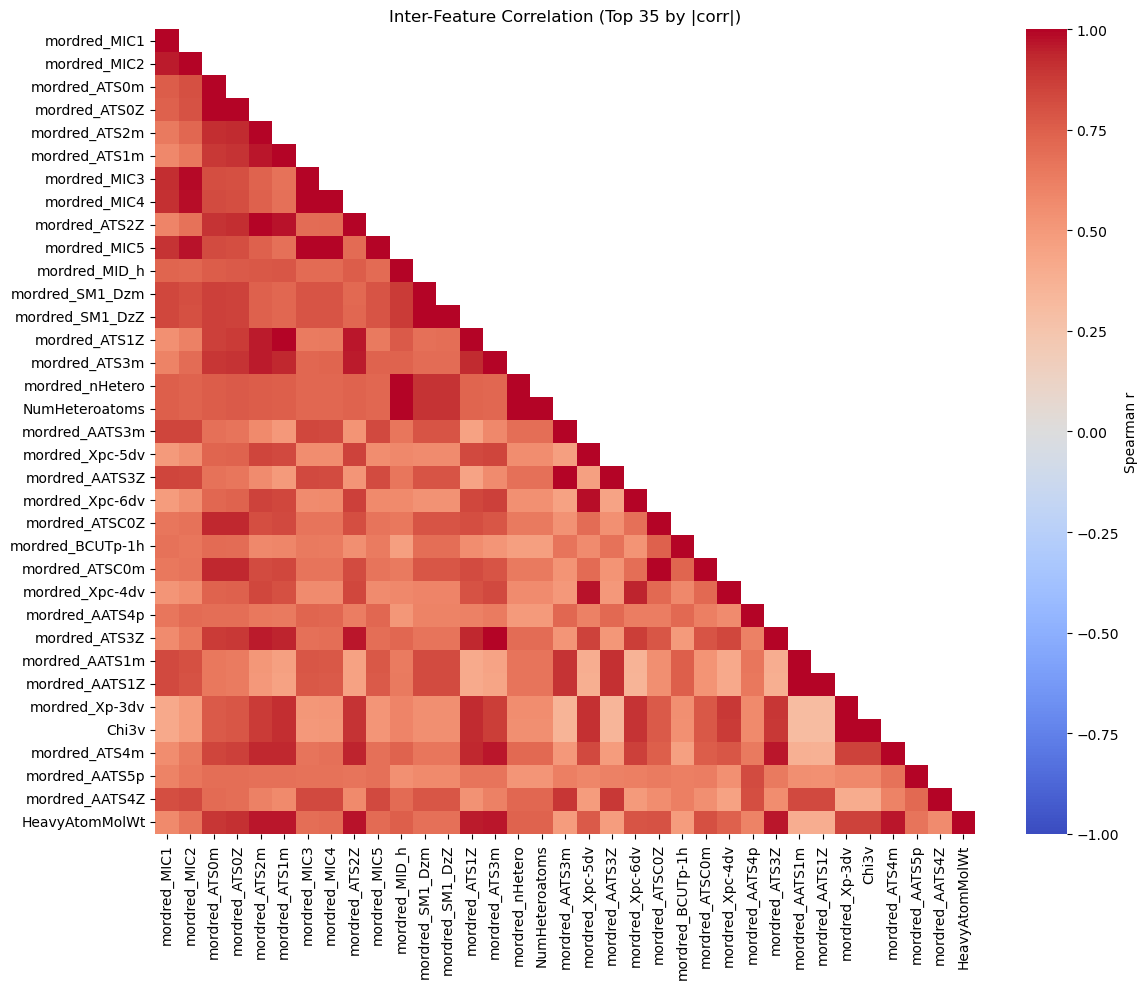


Top highly correlated pairs (|r| > 0.8):
           feature_a        feature_b      corr
135  mordred_nHetero   NumHeteroatoms  1.000000
107  mordred_SM1_Dzm  mordred_SM1_DzZ  0.999847
166   mordred_AATS1m   mordred_AATS1Z  0.999641
169   mordred_Xp-3dv            Chi3v  0.999611
84      mordred_MIC4     mordred_MIC5  0.999246
154   mordred_ATSC0Z   mordred_ATSC0m  0.999242
21     mordred_ATS0m    mordred_ATS0Z  0.999119
136   mordred_AATS3m   mordred_AATS3Z  0.998705
67     mordred_ATS1m    mordred_ATS1Z  0.997731
79      mordred_MIC3     mordred_MIC4  0.997660
53     mordred_ATS2m    mordred_ATS2Z  0.996674
130    mordred_ATS3m    mordred_ATS3Z  0.996523
80      mordred_MIC3     mordred_MIC5  0.995507
106    mordred_MID_h   NumHeteroatoms  0.992772
105    mordred_MID_h  mordred_nHetero  0.992772


In [14]:
# Inter-feature redundancy check with optional GPU Spearman correlation
top_n = 35
top_features = corr_df.dropna(subset=['abs_corr']).head(top_n).index.tolist()
df_desc = df[top_features].astype(np.float32)

use_gpu_corr = False
corr_matrix = None

if GPU_AVAILABLE:
    try:
        import cudf
        gdf = cudf.DataFrame.from_pandas(df_desc)
        corr_matrix = gdf.corr(method='spearman').to_pandas()
        use_gpu_corr = True
    except Exception:
        corr_matrix = df_desc.corr(method='spearman')
else:
    corr_matrix = df_desc.corr(method='spearman')

backend_label = 'GPU (cuDF)' if use_gpu_corr else 'CPU (pandas)'
print(f'Correlation backend: {backend_label}')

# Heatmap with upper-triangle mask for readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={'label': 'Spearman r'}
)
ax.set_title(f'Inter-Feature Correlation (Top {top_n} by |corr|)')
plt.tight_layout()
plt.show()

# Identify strongest correlated pairs
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], float(val), abs(float(val))))

pairs_df = pd.DataFrame(pairs, columns=['feature_a', 'feature_b', 'corr', 'abs_corr'])
if len(pairs_df) > 0:
    print('\nTop highly correlated pairs (|r| > 0.8):')
    print(pairs_df.sort_values('abs_corr', ascending=False).head(15)[['feature_a', 'feature_b', 'corr']])
else:
    print('\nNo feature pairs above |r| > 0.8 in selected subset.')

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Top 20 coefficients by absolute magnitude:
            Feature   Coefficient      Abs_Coef
33              Ipc  3.256731e-21  3.256731e-21
521   mordred_ATS8i  5.696232e-37  5.696232e-37
527   mordred_ATS8v  5.307944e-37  5.307944e-37
510   mordred_ATS7i  5.214323e-37  5.214323e-37
516   mordred_ATS7v  5.182519e-37  5.182519e-37
505   mordred_ATS6v  4.573310e-37  4.573310e-37
499   mordred_ATS6i  4.097497e-37  4.097497e-37
494   mordred_ATS5v  3.991004e-37  3.991004e-37
488   mordred_ATS5i  3.650782e-37  3.650782e-37
483   mordred_ATS4v  3.554642e-37  3.554642e-37
477   mordred_ATS4i  3.312178e-37  3.312178e-37
472   mordred_ATS3v  2.992265e-37  2.992265e-37
466   mordred_ATS3i  2.485620e-37  2.485620e-37
461   mordred_ATS2v  2.236373e-37  2.236373e-37
522   mordred_ATS8m  1.885922e-37  1.885922e-37
511   mordred_ATS7m  1.826312e-37  1.826312e-37
455   mordred_ATS2i  1.767447e-37  1.767447e-37
1573  mordred_WPath  1.749736e-37  1.749736e-37
500   mordred_ATS6m  1.543118e-37  1.543118e-

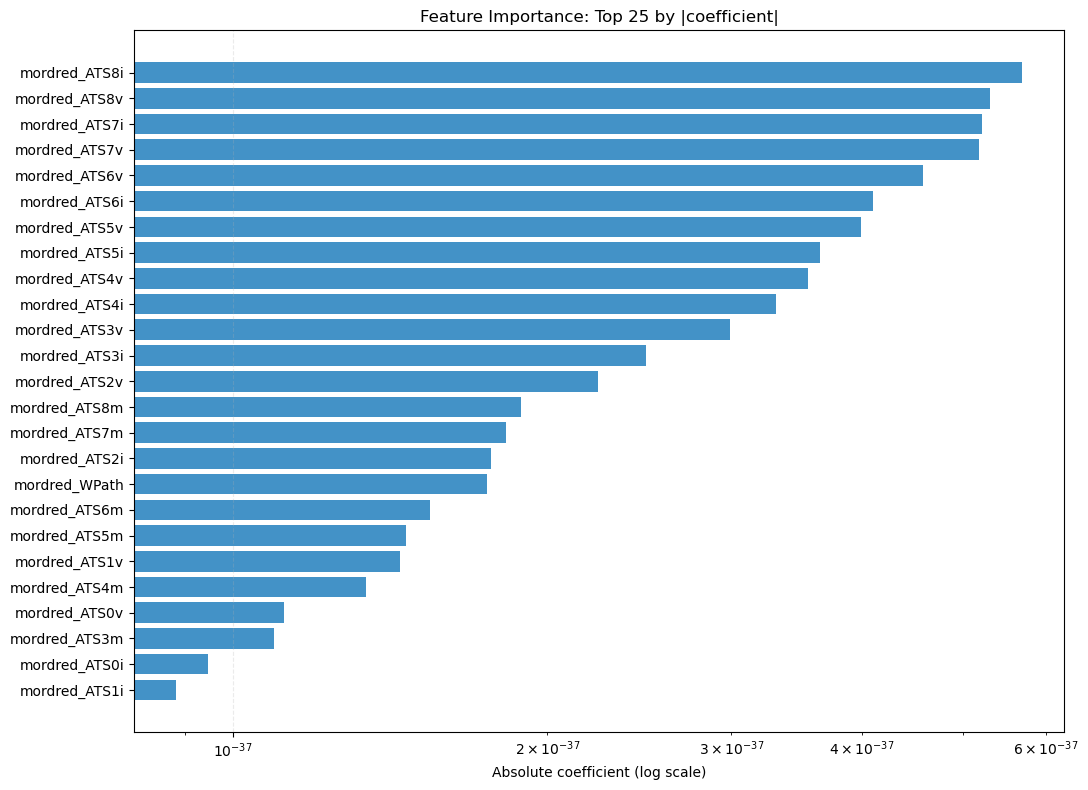

In [16]:
# Feature importance via Linear Regression (GPU if available)
X = df[descriptor_cols].fillna(df[descriptor_cols].mean())
y = df['Y']

if GPU_AVAILABLE:
    # Train on GPU with cuML
    X_gpu = cp.asarray(X.values, dtype=cp.float32)
    y_gpu = cp.asarray(y.values, dtype=cp.float32)
    lr = cuLinearRegression()
    lr.fit(X_gpu, y_gpu)
    y_pred = lr.predict(X_gpu)
    coefs = cp.asnumpy(lr.coef_).ravel()
    model_r2 = float(r2_score(cp.asnumpy(y_gpu), cp.asnumpy(y_pred)))
else:
    # CPU fallback
    lr = LinearRegression()
    lr.fit(X, y)
    coefs = lr.coef_
    model_r2 = float(lr.score(X, y))

coef_df = pd.DataFrame({
    'Feature': descriptor_cols,
    'Coefficient': coefs,
    'Abs_Coef': np.abs(coefs)
}).sort_values('Abs_Coef', ascending=False)

print('Top 20 coefficients by absolute magnitude:')
print(coef_df.head(20)[['Feature', 'Coefficient', 'Abs_Coef']])
print(f'\nModel R² Score: {model_r2:.4f}')

# Visualization: use log scale and avoid single dominant coefficient flattening everything
top_k_coef = 25
plot_coef = coef_df.head(top_k_coef).copy()

if len(plot_coef) > 1 and plot_coef.iloc[0]['Abs_Coef'] > 20 * plot_coef.iloc[1]['Abs_Coef']:
    print('\nNote: dominant first coefficient detected; plotting next top coefficients for readability.')
    plot_coef = coef_df.iloc[1:top_k_coef + 1].copy()

plot_coef = plot_coef.sort_values('Abs_Coef')
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_coef['Feature'], plot_coef['Abs_Coef'], color='#2e86c1', alpha=0.9)
ax.set_xscale('log')
ax.set_xlabel('Absolute coefficient (log scale)')
ax.set_title(f'Feature Importance: Top {len(plot_coef)} by |coefficient|')
ax.grid(alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.show()

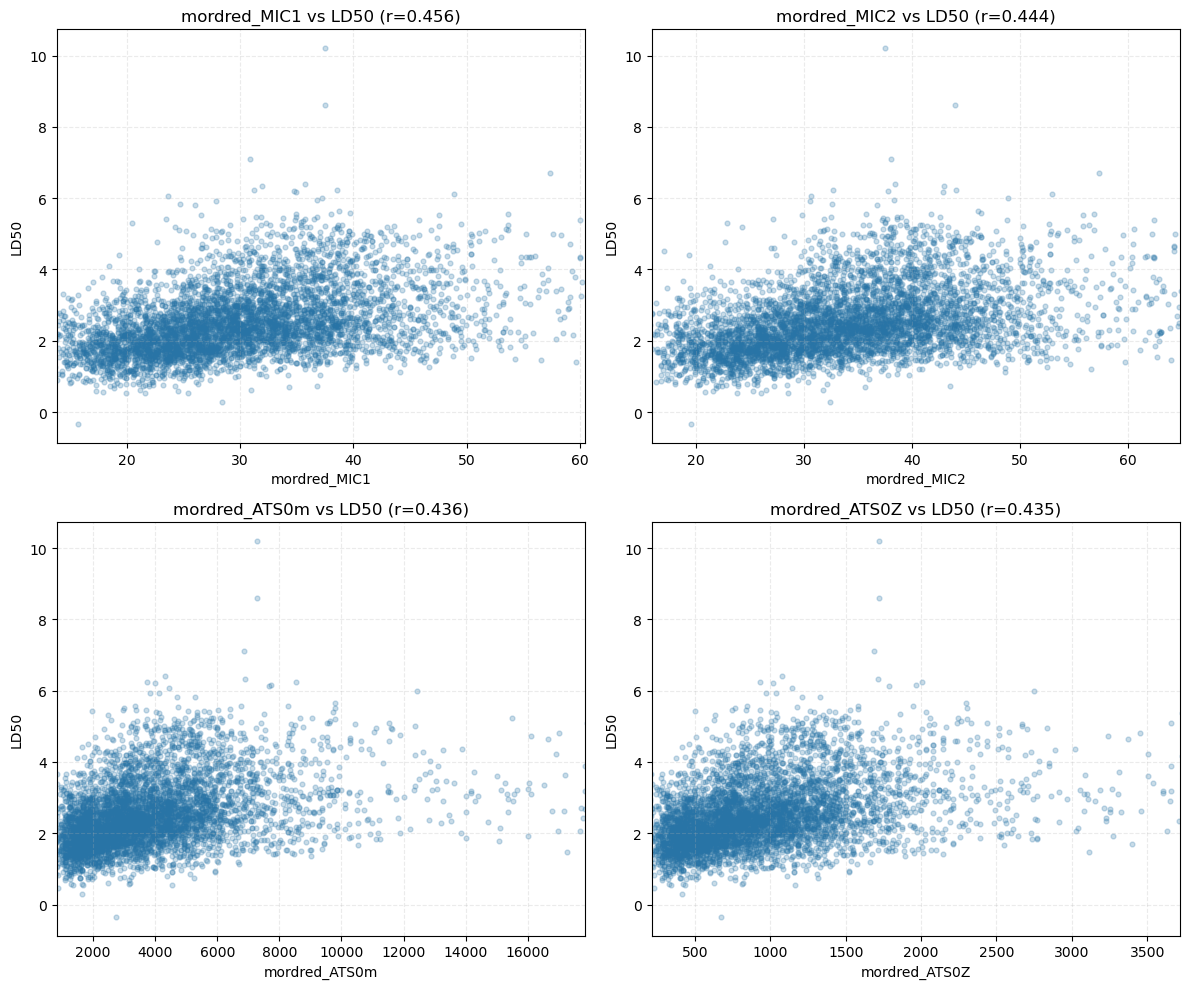

In [17]:
# Scatter plots: Top features vs target
top_features = corr_df.dropna(subset=['corr']).head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    valid_mask = (df[feat].notna()) & (df['Y'].notna())
    x = df[feat][valid_mask]
    y_feat = df['Y'][valid_mask]

    axes[idx].scatter(x, y_feat, alpha=0.25, s=12, color='#2874a6')
    x_low, x_high = np.percentile(x, [1, 99])
    axes[idx].set_xlim(x_low, x_high)

    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('LD50')
    corr_val = corr_df.loc[feat, 'corr']
    axes[idx].set_title(f'{feat} vs LD50 (r={corr_val:.3f})')
    axes[idx].grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()